In [1]:
import pandas as pd
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

prediction_ref = '../model_predictions/token_statistics_lstm_predictions.parquet'

In [2]:


from custom_datasets.BayesRiskDataset.BayesRiskDatasetLoader import BayesRiskDatasetLoader

# Load the validation dataset
n_hypothesis = 100
n_references = 1000
utility = "comet"

dataset_dir = 'predictive/tatoeba-de-en/data/raw/'
dataset_loader = BayesRiskDatasetLoader('validation_predictive', n_hypothesis, n_references,
                                              "ancestral", utility, develop=False,
                                              base=dataset_dir)
val_df = dataset_loader.load(type="pandas").data




C:\Users\gerso\anaconda3\envs\thesis\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load the predictions

predictions_df = pd.read_parquet(prediction_ref)

In [4]:
predictions_df

,source,hypotheses,predictions
0,Ich spreche überhaupt kein Deutsch.,"[I don't speak German at all., I can't speak G...","[0.948549747467041, 0.9865174293518066, 0.8950..."
1,Ich war einmal in deinem Alter.,"[I was once your age., I was your age once., I...","[0.9132806062698364, 0.6977211833000183, 0.450..."
2,"Ich bat Tom, sich mit mir zu treffen.","[I asked Tom to meet me., I asked Tom to meet ...","[1.094623327255249, 0.8426909446716309, -0.351..."
3,Sie will wirklich gehen.,"[She really wants to go., She wants to really ...","[1.1053292751312256, 0.7570067048072815, 0.915..."
4,Die Deutschen lieben Bier und Würstchen.,"[Germans love beer andore., Germans love beer ...","[-0.7709825038909912, -0.9839602708816528, -1...."
...,...,...,...
2495,Der AStA betreibt eine Kneipe auf dem Campus.,"[The laboratory A football runs a bar on mad.,...","[-1.1870310306549072, -1.2455521821975708, -1...."
2496,"Da wo mein Herz ist, bin ich zuhause.","[To the heart, I'm home., That's where my hear...","[-0.5458823442459106, 0.47392967343330383, 0.1..."
2497,Ich mag seinen Pullover.,"[I like his sweater., I love his sweater., I l...","[1.126786708831787, 0.9609667062759399, 0.9379..."
2498,"Weißt du, was mich am meisten ärgert, Tom?","[Do you know what consists of me the most, Tom...","[-0.05190935730934143, 0.5865663886070251, -0...."


In [5]:
from utilities.preprocess.Preprocess import UtilitiesToAverage
preprocess_f = UtilitiesToAverage()
val_df = preprocess_f(val_df)
val_df

,source,target,count,hypotheses,utilities_count,utilities
0,Ich spreche überhaupt kein Deutsch.,I can't speak German at all.,"[28, 51, 7, 7, 1, 1, 1, 1, 1, 1, 1]","[I don't speak German at all., I can't speak G...","[56, 396, 385, 14, 88, 8, 1, 2, 7, 6, 1, 2, 1,...","[0.9981588199064135, 0.9707253898605704, 0.832..."
1,Ich war einmal in deinem Alter.,I was your age once.,"[32, 10, 1, 45, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1]","[I was once your age., I was your age once., I...","[10, 500, 285, 1, 91, 1, 1, 1, 13, 1, 10, 4, 2...","[0.8151286403425038, 0.7690605895407497, 0.841..."
2,"Ich bat Tom, sich mit mir zu treffen.",I asked Tom to come see me.,"[92, 2, 1, 3, 1, 1]","[I asked Tom to meet me., I asked Tom to meet ...","[944, 1, 1, 15, 7, 1, 1, 12, 1, 4, 1, 1, 1, 2,...","[1.1117507179379462, 0.9197503201290965, -0.23..."
3,Sie will wirklich gehen.,She really wants to go.,"[87, 1, 11, 1]","[She really wants to go., She wants to really ...","[929, 54, 1, 5, 6, 1, 1, 1, 2]","[1.0420129651129246, 0.8537840292602777, 0.817..."
4,Die Deutschen lieben Bier und Würstchen.,Germans love beer and sausages.,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[Germans love beer andore., Germans love beer ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[-0.23624300258420408, -0.49456395729258656, -..."
...,...,...,...,...,...,...
2495,Der AStA betreibt eine Kneipe auf dem Campus.,The Students' Union runs a bar on campus.,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[The laboratory A football runs a bar on mad.,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[-1.180682732462883, -1.2797985309362412, -1.2..."
2496,"Da wo mein Herz ist, bin ich zuhause.",Home is where the heart is.,"[1, 2, 2, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, ...","[To the heart, I'm home., That's where my hear...","[16, 4, 1, 15, 1, 1, 4, 3, 1, 43, 8, 2, 1, 23,...","[-0.5391107898429036, 0.05757707807607949, -0...."
2497,Ich mag seinen Pullover.,I like this sweater.,"[96, 3, 1]","[I like his sweater., I love his sweater., I l...","[956, 38, 2, 1, 1, 1, 1]","[1.1970521496534348, 0.9850568935573101, -0.79..."
2498,"Weißt du, was mich am meisten ärgert, Tom?",Do you know what annoys me the most Tom?,"[1, 1, 1, 1, 1, 10, 8, 5, 1, 2, 1, 1, 21, 1, 1...","[Do you know what consists of me the most, Tom...","[1, 225, 73, 1, 69, 1, 10, 1, 1, 1, 1, 16, 1, ...","[-0.6525051297377795, 0.14281816098466515, -0...."


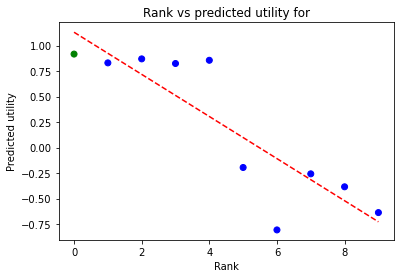

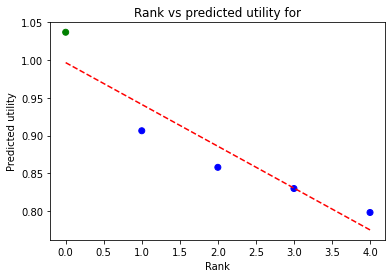

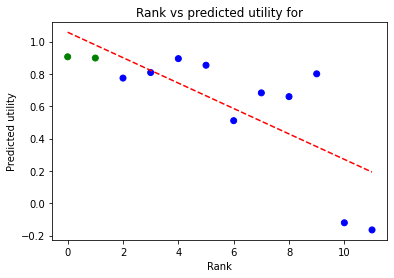

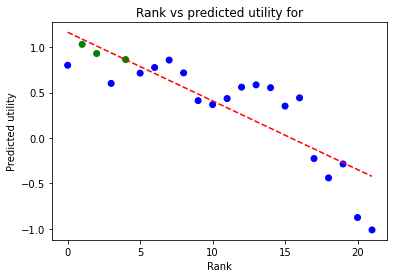

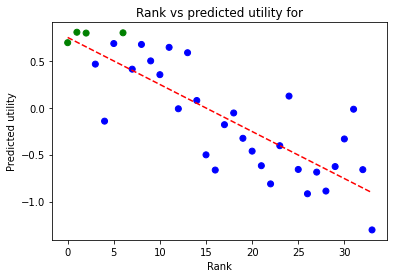

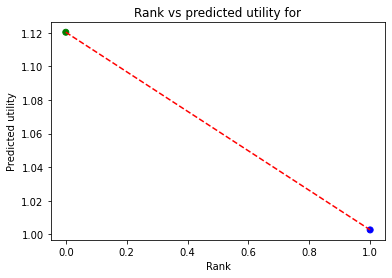

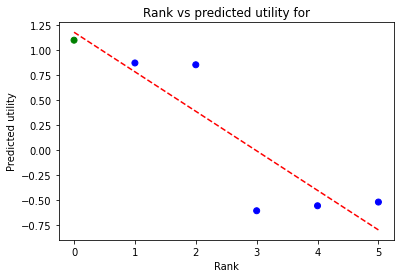

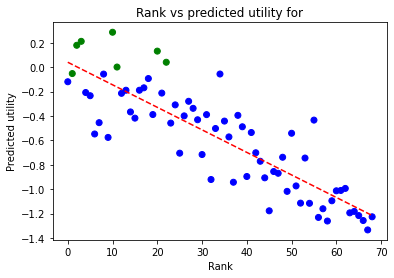

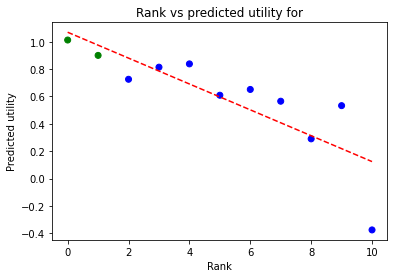

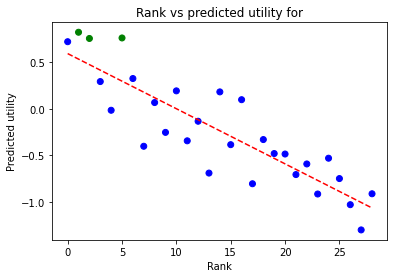

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import math
np.random.seed(5)
indices = np.random.choice(2500, 10)
for i in indices:

    val_row = val_df.iloc[i]
    predicted_row = predictions_df.iloc[i]
    


    predicted_means = np.array(predicted_row["predictions"])
    target_means = val_row["utilities"]

    sorted_indices = np.argsort(target_means)[::-1]

    predicted_means_sorted = predicted_means[sorted_indices]
    x = np.arange(0, len(predicted_means_sorted))

    sorted_indices_predicted = np.argsort(predicted_means_sorted)[::-1]

    colors = ["b"]  * len(predicted_means)

    top_10 = math.ceil(0.1 * len(sorted_indices_predicted)) 
    for j in range(top_10):
        c = sorted_indices_predicted[j]
        colors[c] = 'g'



    z = np.polyfit(x, predicted_means_sorted, 1)
    p = np.poly1d(z)
    plt.plot(x,p(x),"r--")






    plt.scatter(x, predicted_means_sorted, marker='o', c= colors,)
    plt.xlabel('Rank')
    plt.ylabel("Predicted utility")
    plt.title("Rank vs predicted utility for")


    plt.show()

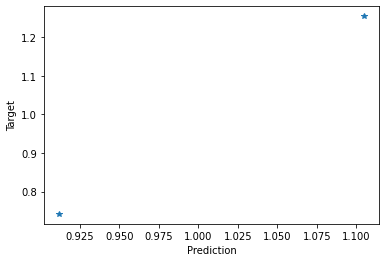

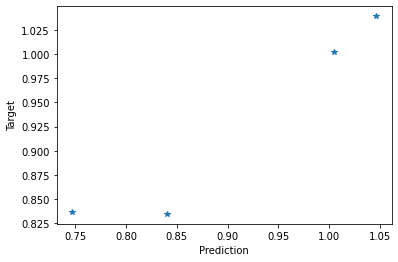

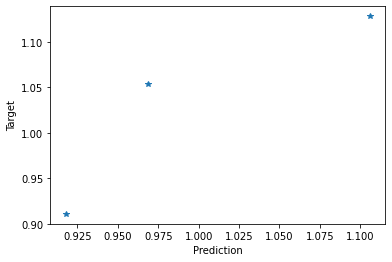

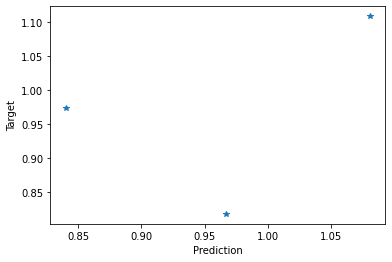

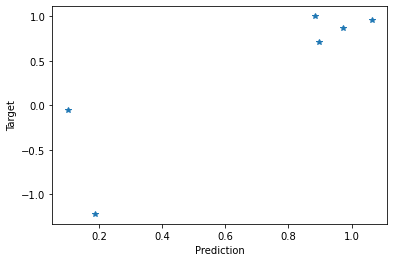

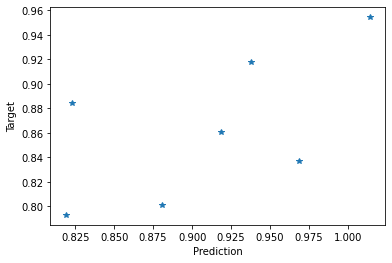

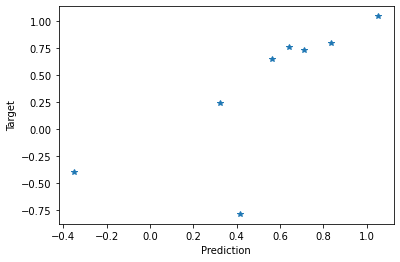

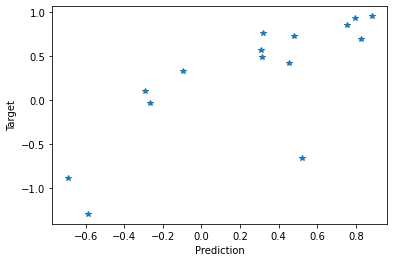

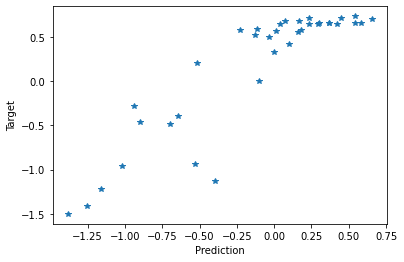

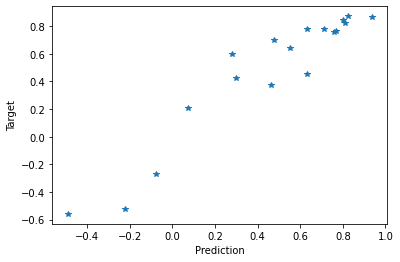

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import math
np.random.seed(1)
indices = np.random.choice(2500, 10)
for i in indices:

    val_row = val_df.iloc[i]
    predicted_row = predictions_df.iloc[i]
    


    predicted_means = np.array(predicted_row["predictions"])
    target_means = val_row["utilities"]
    
    plt.plot(predicted_means,target_means, '*')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.show()
    


In [8]:
# Rank correlation Uses: https://arxiv.org/pdf/2009.09025.pdf
from tqdm import tqdm

temp = predictions_df["predictions"].to_list()
all_predictions = []
for t in tqdm(temp):
    all_predictions += t.tolist()
print(all_predictions[:10])
all_predictions = np.array(all_predictions)
temp = val_df["utilities"].to_list()
all_true_values = []
for t in tqdm(temp):
    all_true_values += t
all_true_values = np.array(all_true_values)
print(len(predictions_df["predictions"].to_list()))
print(len(val_df["utilities"].to_list()))
for i, (x, y) in enumerate(zip(predictions_df["predictions"].to_list(), val_df["utilities"].to_list())):
    assert len(x) == len(y), "{}: {} != {}".format(i, x, y)




100%|██████████████████████████████████████████████████████████████████████████| 2500/2500 [00:00<00:00, 847745.17it/s]


[0.948549747467041, 0.9865174293518066, 0.8950117826461792, 0.8680992722511292, 0.5492957234382629, 0.7653051614761353, -0.18938466906547546, 0.842903196811676, 0.18614593148231506, 0.5141540169715881]


100%|█████████████████████████████████████████████████████████████████████████| 2500/2500 [00:00<00:00, 1261368.94it/s]

2500
2500


In [9]:
print(val_df.iloc[1492])

source                                           Tom braucht Arbeit.
target                                               Tom needs work.
count                                              [79, 18, 1, 1, 1]
hypotheses         [Tom needs work., Tom needs a job., Tom needs ...
utilities_count    [832, 149, 2, 1, 1, 1, 1, 4, 1, 1, 1, 1, 1, 1,...
utilities          [1.1614710242599249, 0.8566036401167512, 0.176...
Name: 1492, dtype: object


In [10]:

print(val_df.iloc[1492])

source                                           Tom braucht Arbeit.
target                                               Tom needs work.
count                                              [79, 18, 1, 1, 1]
hypotheses         [Tom needs work., Tom needs a job., Tom needs ...
utilities_count    [832, 149, 2, 1, 1, 1, 1, 4, 1, 1, 1, 1, 1, 1,...
utilities          [1.1614710242599249, 0.8566036401167512, 0.176...
Name: 1492, dtype: object


In [11]:
print(all_true_values.shape)
print(all_predictions.shape)

(97444,)
(97444,)


In [12]:
from scipy import stats

rho, pval = stats.spearmanr(all_predictions, all_true_values)
print(rho)
print(pval)

0.8857266352009985
0.0


In [13]:
# NExt compute the MSE
MSE = np.mean((all_true_values - all_predictions)**2)
print("MSE: ", MSE)

MSE:  0.10575591944699736


In [14]:
# Next we check what happens if we use it as a decision rule:

# Pick the highest scoring one

def to_highest_scoring(x):
    max_index = np.argmax(x["predictions"])
    best = x["hypotheses"][max_index]
    
    return best

best_hypotheses = predictions_df.apply(to_highest_scoring, axis=1)
best_hypotheses

0                   I can't speak German at all.
1                         I used to be your age.
2                        I asked Tom to meet me.
3                        She really wants to go.
4            The Germans love beer and pumpkins.
                          ...                   
2495         The bicyclesa runs a bar on campus.
2496            Where my heart is, I am at home.
2497                         I like his sweater.
2498    Do you know what annoy me the most, Tom?
2499           Which party are you listening to?
Length: 2500, dtype: object

In [15]:
# Get the top 10
from math import ceil
def top_10(x):
    '''
    First filters the top 10.
    Then keep the highest scoring one based on the ground truth
    '''
    
    
    if len(x["hypotheses"]) <= 1:
        return x["hypotheses"]
    sorted_indices = np.argsort(x["predictions"])
    
    # First get the top 25 % indices
    top = ceil(0.25 * len(x["predictions"]))
    top_indices = sorted_indices[-top:]
    
    
    # Get the ground truth score
    top_n = np.array(x["ground_truth"])[top_indices]
    
    
    # Get the best hypothesis out of it
    best = np.max(top_n)
    best_index = np.where(x["ground_truth"] == best)[0]
    best = x["hypotheses"][best_index]
    
    return best
predictions_df["ground_truth"] = val_df["utilities"]



top_filtered = predictions_df.apply(top_10, axis=1)
top_filtered

0                        [I don't speak German at all.]
1                              [I used to be your age.]
2                             [I asked Tom to meet me.]
3                             [She really wants to go.]
4               [The Germans love beer and vegetables.]
                             ...                       
2495    [TheèsA A ran a bar that works on the subject.]
2496                 [Where my heart is, I am at home.]
2497                              [I like his sweater.]
2498            [Do you know what annoys me most, Tom?]
2499             [To which party are you listening to?]
Length: 2500, dtype: object

In [16]:
x = predictions_df.iloc[4]
sorted_indices = np.argsort(x["predictions"])

# First get the top 25 % indices
top = ceil(0.25 * len(x["predictions"]))
top_indices = sorted_indices[-top:]


# Get the ground truth score
top_n = np.array(x["ground_truth"])[top_indices]


# Get the best hypothesis out of it
best = np.max(top_n)
best_index = np.where(x["ground_truth"] == best)[0]
best = x["hypotheses"][best_index]
    

In [17]:
import itertools
def get_concordants_and_discordants(pred, true_value):
    
    concordants = 0
    discordants = 0
    
    # First we create all pairs:
    for i, j in itertools.product(range(len(pred)), range(len(pred))):
        if i != j:
            
            
            # If they agree on the order
            if (pred[i] > pred[j] and true_value[i] > true_value[j]) or (pred[i] < pred[j] and true_value[i] < true_value[j]):
                concordants += 1
            else:
                discordants += 1
    return concordants, discordants

def get_pearson_tau(predictions, true_values):
    
    total_concordants = 0
    total_discordants = 0
    for pred, true_value in tqdm(zip(predictions, true_values), total=len(predictions)):
        concordants, discordants = get_concordants_and_discordants(pred, true_value)
        total_concordants += concordants
        total_discordants += discordants
        
        
    
    return (concordants - discordants) / (concordants + discordants)
predictions_list = predictions_df["predictions"].to_list()
true_values_list = val_df["utilities"].to_list()

pearson_tau = get_pearson_tau(predictions_list, true_values_list)

100%|█████████████████████████████████████████████████████████████████████████████| 2500/2500 [00:02<00:00, 996.47it/s]


In [18]:
print(pearson_tau)

0.5157894736842106


In [ ]:
### Next we look into the comet scores

# First prepare the data: get the targets

# Then select the right params

# THen 